In [106]:
from sklearn.metrics import mean_absolute_error, r2_score

from pycaret.regression import *
import lightgbm as lgb
import mlflow

import pandas as pd


In [107]:
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import boto3
import os

# Configurar sesión de boto3
os.environ['AWS_ACCESS_KEY_ID'] = 'TOKEN_AWS'
os.environ['AWS_SECRET_ACCESS_KEY'] = 'TOKEN_AWS'
os.environ['AWS_DEFAULT_REGION'] = 'us-east-1'


In [109]:
mlflow.set_tracking_uri("http://ec2-54-160-110-158.compute-1.amazonaws.com:5000/")

## Functions

In [110]:
def plot_feature_importance(importance, names, model_type):
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_df = pd.DataFrame(data)

    fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)

    plt.figure(figsize=(10,8))

    sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])

    plt.title(model_type + ' Feature Importance')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature Names')
    
def plot_predictions(y_true, y_pred, title='Predictions'):
    plt.figure(figsize=(5, 5))
    ax = sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
    ax.set(xlabel='Real', ylabel='Predicted', title=title)
    plt.show()

def evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='Metrics'):
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    print(f'MAE Train: {mae_train:.2f}')
    print(f'R2 Train: {r2_train:.2f}')
    print(f'MAE Test: {mae_test:.2f}')
    print(f'R2 Test: {r2_test:.2f}')
    df = pd.DataFrame({ 'model_name': title, 'mae_train':[mae_train], 'r2_train':[r2_train], 'mae_test': [mae_test], 'r2_test': [r2_test] })
    return df

## ALL CROP UNIVERSE MODEL

### Dataset

In [111]:
data = pd.read_csv('../data/universe.csv')

test_year = 2022
random_state = 21

In [112]:
data.head()

,province,country,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8,code
0,abruzzo,italy,2000,1637.739987,-0.129677,1.588276,4.154839,8.701667,14.219355,17.828667,...,0.0,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,IT
1,abruzzo,italy,2001,1598.159992,2.929677,1.700000,7.197097,6.281333,13.248710,16.045000,...,0.0,1.164839,0.823214,1.299355,1.099667,1.762903,1.732333,2.071290,2.157097,IT
2,abruzzo,italy,2002,1595.639976,-0.383226,4.061786,5.908065,7.896667,13.072581,19.241000,...,0.0,0.733871,1.016429,0.975161,1.243000,1.688065,2.105000,2.331613,2.419677,IT
3,abruzzo,italy,2003,1340.019975,1.565806,-2.159643,3.962258,6.703333,15.211290,21.048333,...,0.0,0.940968,0.596071,0.842258,1.079000,1.736129,2.281333,2.144516,2.448065,IT
4,abruzzo,italy,2004,1496.790036,0.126129,2.306897,3.473548,7.638000,9.717097,16.201667,...,0.0,0.823548,0.867931,0.984516,1.447667,1.397419,1.953000,2.074839,2.260323,IT


In [113]:
train = data[data['year'] < test_year].copy()
test  = data[data['year'] == test_year].copy()

In [114]:
train = train[['code','country','province','year','yield']+[c for c in train.columns if '_M' in c]].rename(columns={'code':'country_code'}).copy()
test = test[['code','country','province','year','yield']+[c for c in test.columns if '_M' in c]].rename(columns={'code':'country_code'}).copy()

In [115]:
train.to_csv('../data/train/train_all_crop.csv', index=False)
test.to_csv('../data/test/test_all_crop.csv', index=False)

In [116]:
train_group1 = train[train['country'].isin(['france'])].copy()
train_group2 = train[train['country'].isin(['italy','türkiye','poland','spain'])].copy()
train_group3 = train[~train['country'].isin(['france','italy','türkiye','poland','spain'])].copy()

test_group1 = test[test['country'].isin(['france'])].copy()
test_group2 = test[test['country'].isin(['italy','türkiye','poland','spain'])].copy()
test_group3 = test[~test['country'].isin(['france','italy','türkiye','poland','spain'])].copy()

### Model Group 1

In [117]:
from pycaret.regression import *
s = setup(data = train_group1, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['country_code'],
          categorical_features = ['province','country'],
          experiment_name='all_crop_group1',
          log_experiment=True)

model = create_model('lightgbm')

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(1254, 61)"
4,Transformed data shape,"(1254, 60)"
5,Transformed train set shape,"(877, 60)"
6,Transformed test set shape,"(377, 60)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1167.3407,4600760.2853,2144.9383,0.9775,3.1882,0.8271
1,966.7170,3839449.1586,1959.4512,0.9788,3.2460,0.6161
2,1135.2194,8433291.8402,2904.0131,0.9431,3.6732,1.8673
3,852.5405,4128927.1526,2031.9762,0.9756,3.9522,2.4848
4,877.9563,2581980.9614,1606.8544,0.9858,3.7035,5.1723
5,1072.3658,5055719.5161,2248.4927,0.9763,3.7351,0.7655
6,1096.7593,4541123.3461,2130.9912,0.9817,3.4757,0.4839
7,1492.1494,7300851.8459,2702.0089,0.9654,3.4250,2.8544
8,1252.6452,6967157.1895,2639.5373,0.9772,3.3151,0.7165


In [118]:
from scipy.stats import randint, uniform

param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
}

tuned_lgbm_model_g1 = tune_model(model, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,02:31:37
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,886.7229,2904140.2361,1704.1538,0.9858,1.7993,0.2304
1,1035.7208,4689742.2308,2165.5813,0.9742,2.0538,0.5341
2,1058.6288,9090185.6294,3014.9935,0.9387,2.1262,0.4730
3,753.2616,4348710.0162,2085.3561,0.9743,2.3737,0.4125
4,806.5721,3286973.7187,1813.0013,0.9819,2.1935,3.3321
5,807.7282,4171617.5428,2042.4538,0.9804,2.1255,0.2349
6,719.7993,2333935.3148,1527.7223,0.9906,2.3143,0.3122
7,1076.7884,4292212.4257,2071.7655,0.9796,2.1809,1.9742
8,1269.0079,6760914.8569,2600.1759,0.9779,2.4158,0.7765


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [119]:
predictions_train_lgbm = predict_model(tuned_lgbm_model_g1, data = train_group1)
predictions_test_lgbm = predict_model(tuned_lgbm_model_g1, data = test_group1)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,268.6140,1499756.7639,1224.6456,0.9922,1.0589,0.1053


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1307.1403,8592750.4432,2931.3394,0.9306,1.9399,0.5930


MAE Train: 268.61
R2 Train: 0.99
MAE Test: 1307.14
R2 Test: 0.93


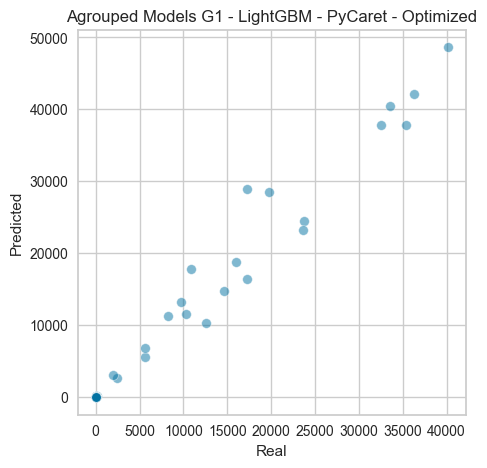

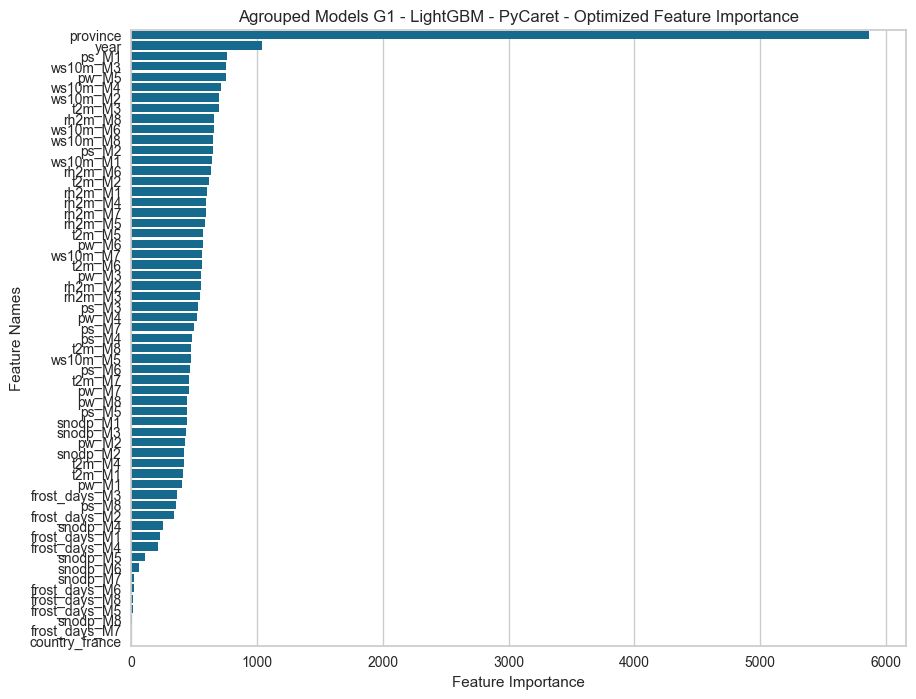

In [120]:
df1 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G1 - LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G1 - LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model_g1.feature_importances_, tuned_lgbm_model_g1.feature_names_in_, 'Agrouped Models G1 - LightGBM - PyCaret - Optimized')

### Model Group 2

In [121]:
from pycaret.regression import *
s = setup(data = train_group2, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['country_code'],
          categorical_features = ['province','country'],
          experiment_name='all_crop_group2',
          log_experiment=True)

model = create_model('lightgbm')

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(2156, 61)"
4,Transformed data shape,"(2156, 63)"
5,Transformed train set shape,"(1509, 63)"
6,Transformed test set shape,"(647, 63)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1952.3969,13974751.9740,3738.2820,0.6018,3.9128,0.5597
1,2106.1905,15553266.6013,3943.7630,0.6715,3.8652,2.5919
2,2225.5965,18389800.5643,4288.3331,0.5317,3.7891,0.6106
3,1580.5689,5831559.8365,2414.8623,0.7839,3.8898,4.5140
4,2288.3182,21468823.0467,4633.4461,0.4463,4.1092,3.1055
5,1738.8473,15196864.8509,3898.3156,0.6549,3.8679,0.9389
6,2419.4422,20046761.1060,4477.3610,0.5955,3.6854,1.5634
7,1703.9579,8703555.1317,2950.1788,0.5198,3.2812,1.3353
8,2184.1046,16206708.0781,4025.7556,0.4904,2.9725,0.5682


In [122]:
from scipy.stats import randint, uniform

param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
}

tuned_lgbm_model_g2 = tune_model(model, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1957.7996,15427678.6630,3927.8084,0.5604,3.8535,0.5684
1,2083.2206,14287983.6629,3779.9449,0.6982,3.8485,1.5247
2,2240.7637,19149865.1241,4376.0559,0.5124,3.9120,0.6795
3,1515.7207,6310066.6816,2511.9846,0.7661,3.7443,0.9119
4,2139.8216,22591649.4554,4753.0674,0.4173,4.0188,1.2907
5,1680.3327,18903548.8239,4347.8212,0.5707,3.6614,1.4050
6,2202.9055,20160382.9788,4490.0315,0.5932,3.4387,1.2864
7,1387.5770,5337790.6679,2310.3659,0.7055,3.1127,1.7757
8,2024.9869,19301426.6792,4393.3389,0.3931,2.8542,0.4860


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [123]:
predictions_train_lgbm = predict_model(tuned_lgbm_model_g2, data = train_group2)
predictions_test_lgbm = predict_model(tuned_lgbm_model_g2, data = test_group2)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,553.2269,4216146.5612,2053.3257,0.8869,1.9630,0.4425


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1974.2248,11115125.2121,3333.9354,0.8127,3.0744,5.5619


MAE Train: 553.23
R2 Train: 0.89
MAE Test: 1974.22
R2 Test: 0.81


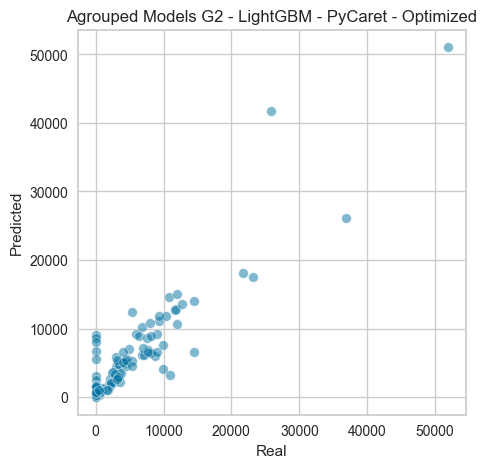

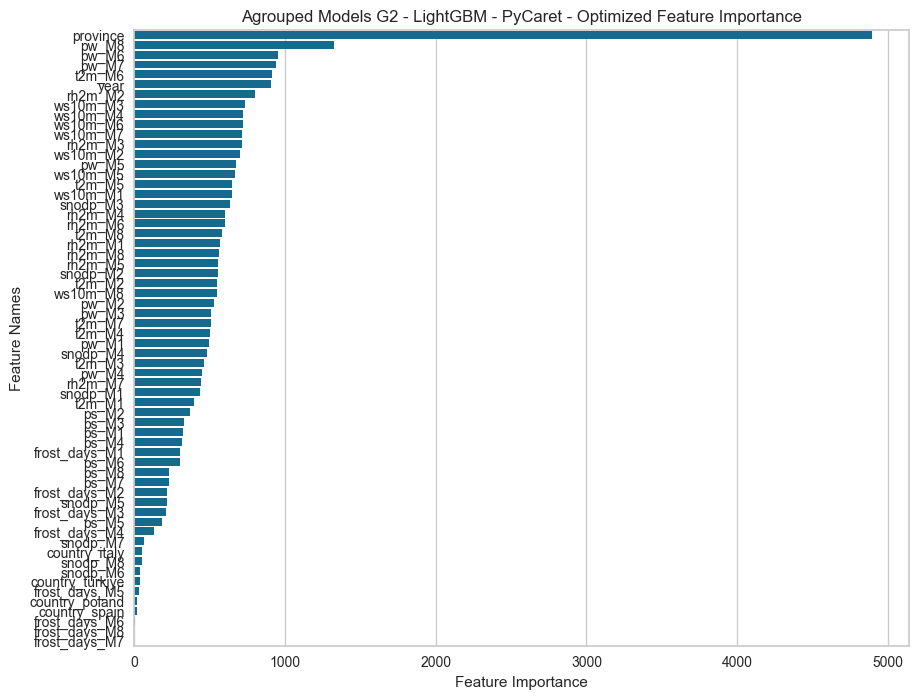

In [124]:
df2 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G2 - LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G2 - LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model_g2.feature_importances_, tuned_lgbm_model_g2.feature_names_in_, 'Agrouped Models G2 - LightGBM - PyCaret - Optimized')

### Model Group 3

In [125]:
from pycaret.regression import *
s = setup(data = train_group3, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['country_code'],
          categorical_features = ['province','country'],
          experiment_name='all_crop_group3',
          log_experiment=True)

model = create_model('lightgbm')

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(5676, 61)"
4,Transformed data shape,"(5676, 60)"
5,Transformed train set shape,"(3973, 60)"
6,Transformed test set shape,"(1703, 60)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,669.3414,2204052.9424,1484.6053,0.7592,3.5073,2.6195
1,724.5071,2353752.9320,1534.1946,0.7611,3.4681,0.5784
2,552.6000,1399610.8264,1183.0515,0.8335,3.4253,1.5162
3,585.1116,1505612.6511,1227.0341,0.8111,3.6634,2.5451
4,680.5160,2167081.3419,1472.1010,0.7938,3.4362,0.6601
5,910.6511,4743668.2026,2177.9964,0.6697,3.4243,0.6457
6,634.4941,1951933.2492,1397.1160,0.7587,3.5850,0.8962
7,665.4086,2318796.6683,1522.7596,0.7178,3.5764,0.7224
8,718.1182,2349446.7663,1532.7905,0.7672,3.6628,1.0966


In [126]:
from scipy.stats import randint, uniform

param_distributions = {
    'n_estimators': randint(50, 1000),            # Número de árboles
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
}

tuned_lgbm_model_g3 = tune_model(model, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,606.5415,2071013.7501,1439.1017,0.7738,3.0305,1.5334
1,657.7460,2194867.5081,1481.5085,0.7772,3.1131,0.5479
2,523.6644,1397725.4033,1182.2544,0.8337,3.0688,1.1131
3,538.8225,1475748.0906,1214.8037,0.8149,3.2630,1.0738
4,639.0901,2261176.5263,1503.7209,0.7848,3.1119,0.5891
5,861.6051,4793602.8147,2189.4298,0.6662,3.1382,0.5843
6,572.4552,1861350.8442,1364.3133,0.7699,3.2263,0.5148
7,580.0810,2073048.6330,1439.8085,0.7477,3.1460,0.7762
8,589.1337,1822969.7986,1350.1740,0.8193,3.2403,1.3606


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [127]:
predictions_train_lgbm = predict_model(tuned_lgbm_model_g3, data = train_group3)
predictions_test_lgbm = predict_model(tuned_lgbm_model_g3, data = test_group3)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,169.0943,479699.4703,692.6034,0.9477,2.0415,0.4237


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,581.0961,994336.0782,997.1640,0.8711,3.4756,0.9791


MAE Train: 169.09
R2 Train: 0.95
MAE Test: 581.10
R2 Test: 0.87


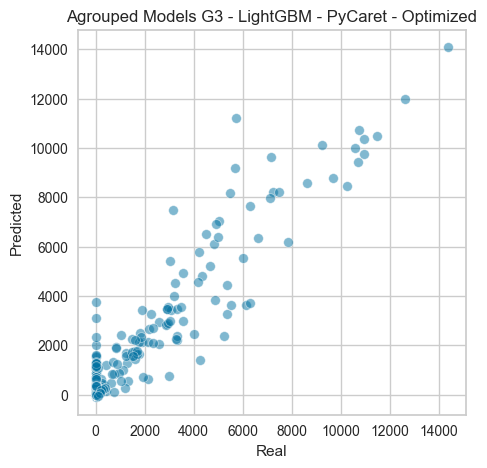

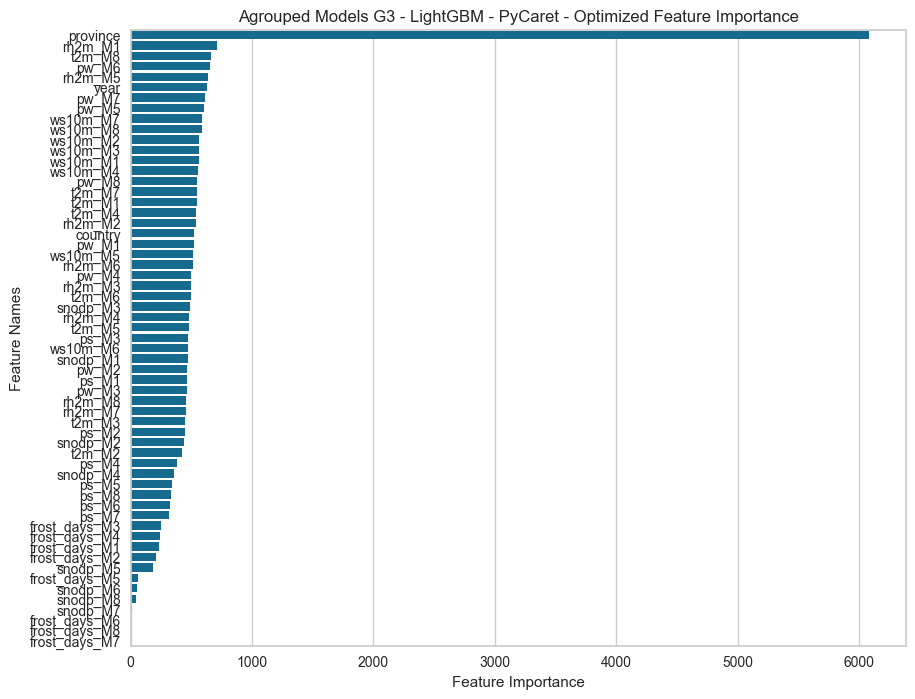

In [128]:
df3 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G3 - LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G3 - LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model_g3.feature_importances_, tuned_lgbm_model_g3.feature_names_in_, 'Agrouped Models G3 - LightGBM - PyCaret - Optimized')

### Model Registry

In [129]:
client = mlflow.tracking.MlflowClient()

In [130]:
experiments = (client.search_experiments())

In [131]:
experiment_g1 = list(filter(lambda k: k.name=='all_crop_group1', experiments))[0]
experiment_g2 = list(filter(lambda k: k.name=='all_crop_group2', experiments))[0]
experiment_g3 = list(filter(lambda k: k.name=='all_crop_group3', experiments))[0]

In [132]:
experiment_g1_id = experiment_g1.experiment_id
experiment_g2_id = experiment_g2.experiment_id
experiment_g3_id = experiment_g3.experiment_id

In [133]:
runs_g1 = mlflow.MlflowClient().search_runs(
    experiment_ids=experiment_g1_id,
    filter_string="",
    max_results=2,
    order_by=["metrics.MAE DESC"],
    run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY
)

runs_g2 = mlflow.MlflowClient().search_runs(
    experiment_ids=experiment_g2_id,
    filter_string="",
    max_results=2,
    order_by=["metrics.MAE DESC"],
    run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY
)

runs_g3 = mlflow.MlflowClient().search_runs(
    experiment_ids=experiment_g3_id,
    filter_string="",
    max_results=2,
    order_by=["metrics.MAE DESC"],
    run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY
)

In [134]:
run_g1 = runs_g1[0]
run_g2 = runs_g2[0]
run_g3 = runs_g3[0]

In [135]:
run_g1_id = run_g1.data.tags['Run ID']
run_g2_id = run_g2.data.tags['Run ID']
run_g3_id = run_g3.data.tags['Run ID']

In [136]:
mlflow.register_model(f'runs:/{run_g1_id}/model', 'all_crop_group1_model')
mlflow.register_model(f'runs:/{run_g2_id}/model', 'all_crop_group2_model')
mlflow.register_model(f'runs:/{run_g3_id}/model', 'all_crop_group3_model')

Registered model 'all_crop_group1_model' already exists. Creating a new version of this model...
2024/12/04 03:25:14 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation.                     Model name: all_crop_group1_model, version 5
Created version '5' of model 'all_crop_group1_model'.
Registered model 'all_crop_group2_model' already exists. Creating a new version of this model...
2024/12/04 03:25:14 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation.                     Model name: all_crop_group2_model, version 2
Created version '2' of model 'all_crop_group2_model'.
Registered model 'all_crop_group3_model' already exists. Creating a new version of this model...
2024/12/04 03:25:15 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation.                     Model name: all_crop_group3_model, version 2
Created version '2'

<ModelVersion: creation_timestamp=1733300715123, current_stage='None', description='', last_updated_timestamp=1733300715123, name='all_crop_group3_model', run_id='28d4d791c61b477d9421ff5c846ad8dc', run_link='', source='s3://mlflow-forecast-yield-eu/3/28d4d791c61b477d9421ff5c846ad8dc/artifacts/model', status='READY', status_message='', tags={}, user_id='', version='2'>

In [137]:
client.transition_model_version_stage(
    name='all_crop_group1_model',
    version=5,
    stage="Production"
)

client.transition_model_version_stage(
    name='all_crop_group2_model',
    version=2,
    stage="Production"
)

client.transition_model_version_stage(
    name='all_crop_group3_model',
    version=2,
    stage="Production"
)

<ModelVersion: creation_timestamp=1733300715123, current_stage='Production', description='', last_updated_timestamp=1733300735512, name='all_crop_group3_model', run_id='28d4d791c61b477d9421ff5c846ad8dc', run_link='', source='s3://mlflow-forecast-yield-eu/3/28d4d791c61b477d9421ff5c846ad8dc/artifacts/model', status='READY', status_message='', tags={}, user_id='', version='2'>

### Saving Results from testing

In [138]:
logged_model_all_g1 = mlflow.pyfunc.load_model("models:/all_crop_group1_model/Production")
logged_model_all_g2 = mlflow.pyfunc.load_model("models:/all_crop_group2_model/Production")
logged_model_all_g3 = mlflow.pyfunc.load_model("models:/all_crop_group3_model/Production")

In [139]:
test_group1_prd = test_group1.copy()
test_group2_prd = test_group2.copy()
test_group3_prd = test_group3.copy()

In [140]:
test_group1_prd['prediction'] = logged_model_all_g1.predict(test_group1.drop(columns=['yield','country_code']))
test_group2_prd['prediction'] = logged_model_all_g2.predict(test_group2.drop(columns=['yield','country_code']))
test_group3_prd['prediction'] = logged_model_all_g3.predict(test_group3.drop(columns=['yield','country_code']))

MAE Test G1: 934.7828189695011


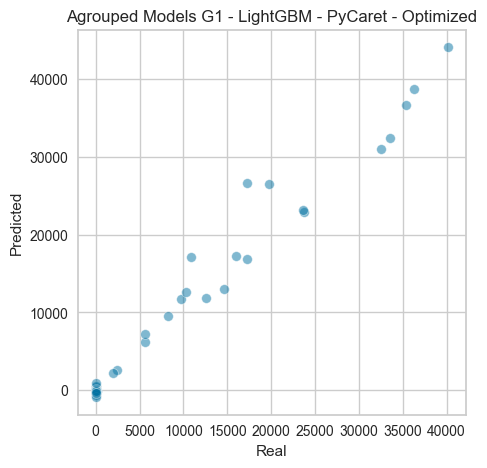

MAE Test G2: 2108.777302171629


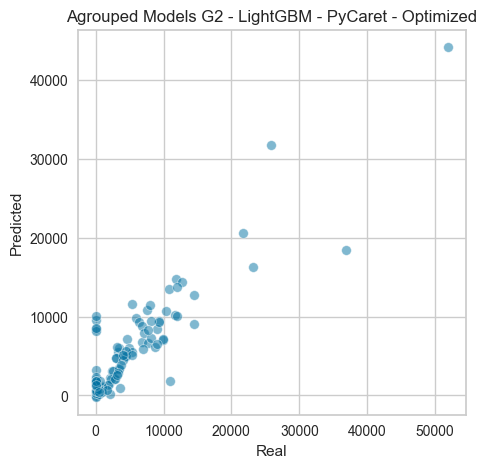

MAE Test G3: 691.9455430521527


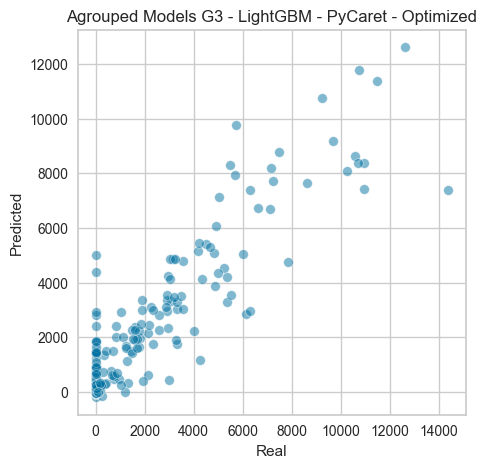

In [141]:
print('============================================================================================')
print('MAE Test G1:', mean_absolute_error(test_group1_prd['yield'], test_group1_prd['prediction']))
plot_predictions(test_group1_prd['yield'], test_group1_prd['prediction'], 
                 title='Agrouped Models G1 - LightGBM - PyCaret - Optimized')
print('============================================================================================')
print('MAE Test G2:', mean_absolute_error(test_group2_prd['yield'], test_group2_prd['prediction']))
plot_predictions(test_group2_prd['yield'], test_group2_prd['prediction'], 
                 title='Agrouped Models G2 - LightGBM - PyCaret - Optimized')
print('============================================================================================')
print('MAE Test G3:', mean_absolute_error(test_group3_prd['yield'], test_group3_prd['prediction']))
plot_predictions(test_group3_prd['yield'], test_group3_prd['prediction'], 
                 title='Agrouped Models G3 - LightGBM - PyCaret - Optimized')

In [142]:
test_all_crops = pd.concat([test_group1_prd, test_group2_prd, test_group3_prd])
test_all_crops = test_all_crops.groupby(['country_code']).agg({'prediction':'sum'}).rename(columns={'prediction':'yield_forecast'}).reset_index()
test_all_crops.to_csv('../data/forecast/EU_2022_all_crops_forecast.csv', index=False)













































## TOP CROP UNIVERSE MODEL

### DataSet

In [68]:
data = pd.read_csv('../data/universe_Harv_Cereals_for_the_production_of_grain_including_seed.csv')

top_crop_name = 'cereals_for_the_production_of_grain_including_seed'

test_year = 2022
random_state = 21

In [69]:
data.head()

,province,country,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8,code
0,abruzzo,italy,2000,421.500000,-0.129677,1.588276,4.154839,8.701667,14.219355,17.828667,...,0.0,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,IT
1,abruzzo,italy,2001,403.899994,2.929677,1.700000,7.197097,6.281333,13.248710,16.045000,...,0.0,1.164839,0.823214,1.299355,1.099667,1.762903,1.732333,2.071290,2.157097,IT
2,abruzzo,italy,2002,386.799988,-0.383226,4.061786,5.908065,7.896667,13.072581,19.241000,...,0.0,0.733871,1.016429,0.975161,1.243000,1.688065,2.105000,2.331613,2.419677,IT
3,abruzzo,italy,2003,348.299988,1.565806,-2.159643,3.962258,6.703333,15.211290,21.048333,...,0.0,0.940968,0.596071,0.842258,1.079000,1.736129,2.281333,2.144516,2.448065,IT
4,abruzzo,italy,2004,399.700012,0.126129,2.306897,3.473548,7.638000,9.717097,16.201667,...,0.0,0.823548,0.867931,0.984516,1.447667,1.397419,1.953000,2.074839,2.260323,IT


In [70]:
train = data[data['year'] < test_year].copy()
test  = data[data['year'] == test_year].copy()

In [71]:
train = train[['code','country','province','year','yield']+[c for c in train.columns if '_M' in c]].rename(columns={'code':'country_code'}).copy()
test = test[['code','country','province','year','yield']+[c for c in test.columns if '_M' in c]].rename(columns={'code':'country_code'}).copy()

In [74]:
train.to_csv(f'../data/train/train_{top_crop_name}.csv', index=False)
test.to_csv(f'../data/test/test_{top_crop_name}.csv', index=False)

In [75]:
train_group1 = train[train['country'].isin(['france'])].copy()
train_group2 = train[train['country'].isin(['italy','türkiye','poland','spain'])].copy()
train_group3 = train[~train['country'].isin(['france','italy','türkiye','poland','spain'])].copy()

test_group1 = test[test['country'].isin(['france'])].copy()
test_group2 = test[test['country'].isin(['italy','türkiye','poland','spain'])].copy()
test_group3 = test[~test['country'].isin(['france','italy','türkiye','poland','spain'])].copy()

### Group 1

In [76]:
from pycaret.regression import *
s = setup(data = train_group1, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['country_code'],
          categorical_features = ['province','country'],
          experiment_name='top_crop_group1',
          log_experiment=True)

model = create_model('lightgbm')

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(1254, 61)"
4,Transformed data shape,"(1254, 60)"
5,Transformed train set shape,"(877, 60)"
6,Transformed test set shape,"(377, 60)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


2024/12/04 01:57:37 INFO mlflow.tracking.fluent: Experiment with name 'top_crop_group1' does not exist. Creating a new experiment.


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,101.4694,41359.2772,203.3698,0.9888,1.7771,1.0081
1,122.3177,85511.6307,292.4237,0.9776,1.6049,0.4481
2,102.1492,80282.6416,283.3419,0.9629,1.6392,2.1541
3,94.7574,79380.4727,281.7454,0.9744,1.8856,50.7624
4,116.5629,56410.6833,237.5093,0.9853,1.9824,0.3930
5,81.1237,34861.4636,186.7122,0.9899,1.7721,0.1743
6,134.2117,142451.6234,377.4276,0.9671,1.7649,3.0666
7,177.9885,139325.0000,373.2626,0.9738,1.7271,5.5815
8,154.2082,137687.1099,371.0621,0.9738,1.7427,1.0441


In [77]:
from scipy.stats import randint, uniform

param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
}

tuned_lgbm_model_g1 = tune_model(model, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,97.6417,47928.9241,218.9268,0.9870,1.0378,0.2447
1,99.1823,36028.6961,189.8123,0.9905,1.2160,0.1669
2,69.7347,29052.1261,170.4468,0.9866,1.2830,1.9516
3,98.5969,70538.7682,265.5914,0.9772,1.4381,81.6073
4,123.0469,104184.9126,322.7769,0.9728,1.3082,0.1884
5,84.8587,40272.3417,200.6797,0.9884,1.3010,0.1386
6,70.8244,28649.8226,169.2626,0.9934,1.2117,0.5248
7,122.4673,59125.5500,243.1575,0.9889,1.1291,0.7349
8,92.5726,33509.1351,183.0550,0.9936,1.1929,0.1368


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [78]:
predictions_train_lgbm = predict_model(tuned_lgbm_model_g1, data = train_group1)
predictions_test_lgbm = predict_model(tuned_lgbm_model_g1, data = test_group1)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,28.0732,12194.5104,110.4288,0.9967,0.8085,0.3675


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,124.9387,80632.1912,283.9581,0.9748,1.4704,6.5422


MAE Train: 28.07
R2 Train: 1.00
MAE Test: 124.94
R2 Test: 0.97


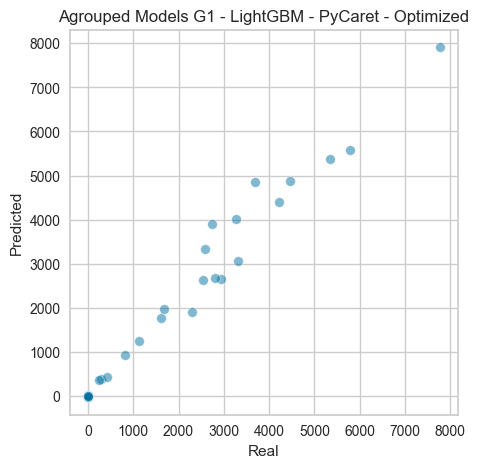

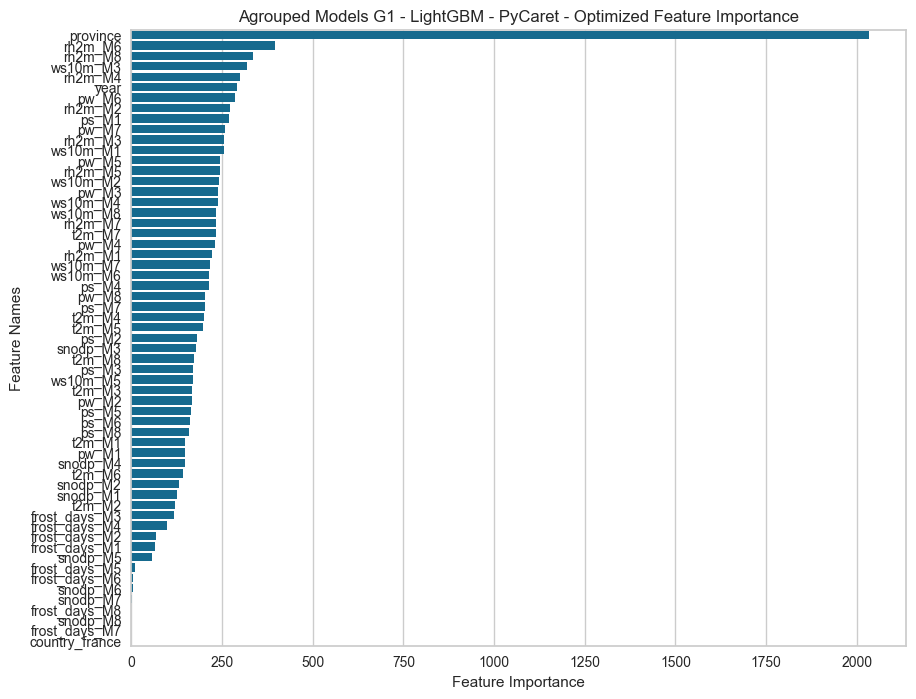

In [79]:
df1 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G1 - LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G1 - LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model_g1.feature_importances_, tuned_lgbm_model_g1.feature_names_in_, 'Agrouped Models G1 - LightGBM - PyCaret - Optimized')

### Group 2

In [80]:
from pycaret.regression import *
s = setup(data = train_group2, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['country_code'],
          categorical_features = ['province','country'],
          experiment_name='top_crop_group2',
          log_experiment=True)

model = create_model('lightgbm')

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(2156, 61)"
4,Transformed data shape,"(2156, 63)"
5,Transformed train set shape,"(1509, 63)"
6,Transformed test set shape,"(647, 63)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


2024/12/04 02:04:00 INFO mlflow.tracking.fluent: Experiment with name 'top_crop_group2' does not exist. Creating a new experiment.


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,398.4112,578186.7833,760.3859,0.7173,3.2856,7.0647
1,403.7155,477536.5808,691.0402,0.6996,3.1563,5.9733
2,405.1745,550567.5564,742.0024,0.6149,3.1057,3.6277
3,337.9234,281037.8176,530.1300,0.8185,3.0673,6.3913
4,354.2310,529389.1870,727.5914,0.5328,3.2962,4.3834
5,288.7919,269325.9078,518.9662,0.8453,2.9917,3.4743
6,444.5760,657977.8165,811.1583,0.6332,2.9264,9.6456
7,314.0697,255663.0496,505.6313,0.7538,2.6520,6.9401
8,403.7891,561044.6669,749.0291,0.6496,2.4302,3.0250


In [81]:
from scipy.stats import randint, uniform

param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
}

tuned_lgbm_model_g2 = tune_model(model, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,373.2974,701196.7670,837.3749,0.6572,3.0669,2.1492
1,369.3967,417264.0172,645.9598,0.7375,3.0581,4.3955
2,398.0485,545322.4008,738.4595,0.6186,3.0584,1.5469
3,289.1393,266662.9396,516.3942,0.8278,2.9094,3.5887
4,304.9459,512786.3901,716.0910,0.5475,3.0127,2.5960
5,306.0498,294349.2604,542.5396,0.8309,2.9185,3.9784
6,408.4830,556761.4476,746.1645,0.6896,2.8301,3.1436
7,288.8716,347184.8261,589.2239,0.6656,2.4218,3.5354
8,371.3311,497585.9178,705.3977,0.6893,2.3294,2.5528


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [82]:
predictions_train_lgbm = predict_model(tuned_lgbm_model_g2, data = train_group2)
predictions_test_lgbm = predict_model(tuned_lgbm_model_g2, data = test_group2)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,99.3550,103293.7796,321.3935,0.9322,1.5792,1.2676


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,307.6828,287469.7176,536.1620,0.8413,2.5010,22.4470


MAE Train: 99.36
R2 Train: 0.93
MAE Test: 307.68
R2 Test: 0.84


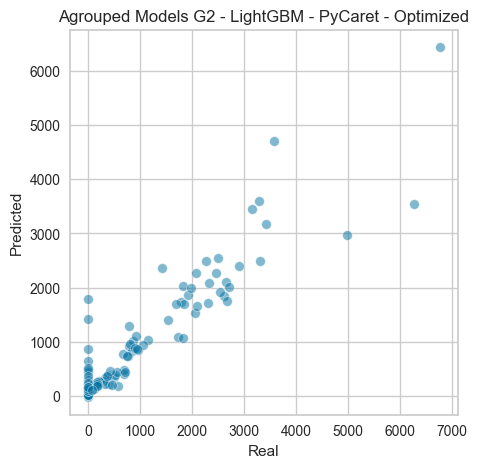

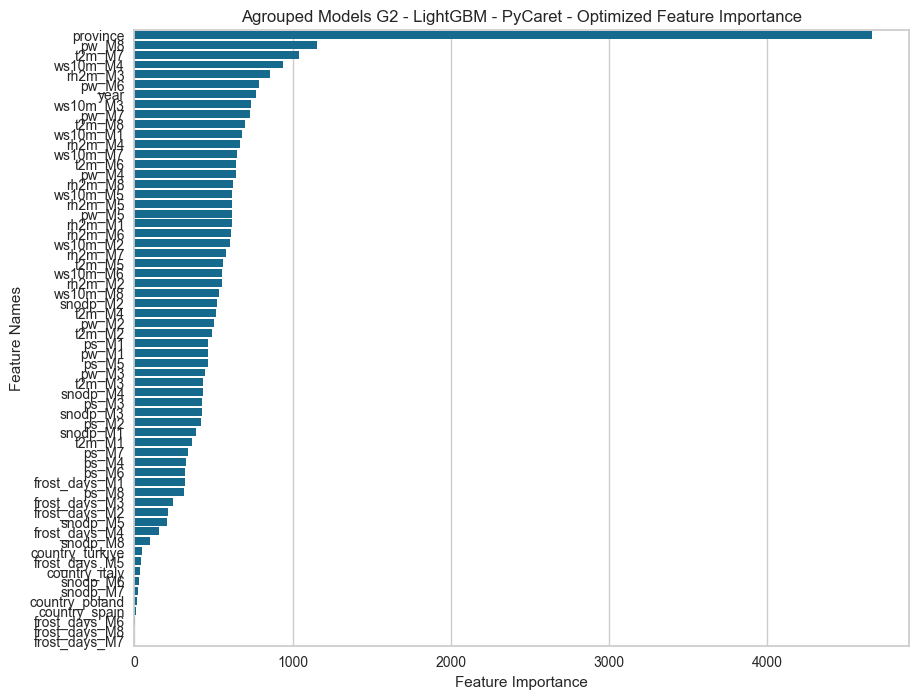

In [83]:
df2 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G2 - LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G2 - LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model_g2.feature_importances_, tuned_lgbm_model_g2.feature_names_in_, 'Agrouped Models G2 - LightGBM - PyCaret - Optimized')

### Group 3

In [84]:
from pycaret.regression import *
s = setup(data = train_group3, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['country_code'],
          categorical_features = ['province','country'],
          experiment_name='top_crop_group3',
          log_experiment=True)

model = create_model('lightgbm')

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(5676, 61)"
4,Transformed data shape,"(5676, 60)"
5,Transformed train set shape,"(3973, 60)"
6,Transformed test set shape,"(1703, 60)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


2024/12/04 02:12:47 INFO mlflow.tracking.fluent: Experiment with name 'top_crop_group3' does not exist. Creating a new experiment.


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,140.9013,96860.2952,311.2239,0.8698,2.6026,20.2648
1,159.8332,124611.6165,353.0037,0.8076,2.6915,2.9889
2,127.8630,72037.8762,268.3987,0.8839,2.6114,3.6533
3,145.0782,109296.5782,330.6003,0.7940,2.7868,4.3067
4,175.3182,163616.2211,404.4950,0.8091,2.5912,12.4076
5,211.0061,332143.2463,576.3187,0.6835,2.6701,1.2549
6,171.3439,153949.3911,392.3639,0.7728,2.7532,3.7612
7,148.7714,114486.6535,338.3588,0.7959,2.6684,2.3175
8,149.8321,100019.9004,316.2592,0.8137,2.6610,6.3916


In [85]:
from scipy.stats import randint, uniform

param_distributions = {
    'n_estimators': randint(50, 1000),            # Número de árboles
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
}

tuned_lgbm_model_g3 = tune_model(model, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,130.1906,94029.2759,306.6419,0.8736,2.3470,3.4985
1,151.7530,127170.8310,356.6102,0.8037,2.5100,2.1243
2,110.7853,70805.9155,266.0938,0.8859,2.3772,2.2960
3,126.0262,95515.0760,309.0551,0.8200,2.5555,1.9372
4,148.8017,116463.6284,341.2677,0.8641,2.3927,1.5577
5,198.7351,312548.8324,559.0607,0.7022,2.4610,0.6603
6,147.8832,123722.8872,351.7426,0.8174,2.5631,2.8169
7,131.0739,85806.8502,292.9281,0.8470,2.4173,1.0101
8,130.7905,96427.6048,310.5279,0.8204,2.3880,2.8034


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [86]:
predictions_train_lgbm = predict_model(tuned_lgbm_model_g3, data = train_group3)
predictions_test_lgbm = predict_model(tuned_lgbm_model_g3, data = test_group3)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,53.0350,28391.1732,168.4968,0.9577,1.9856,1.4345


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,149.9741,105061.6163,324.1321,0.8560,2.4318,2.4933


MAE Train: 53.04
R2 Train: 0.96
MAE Test: 149.97
R2 Test: 0.86


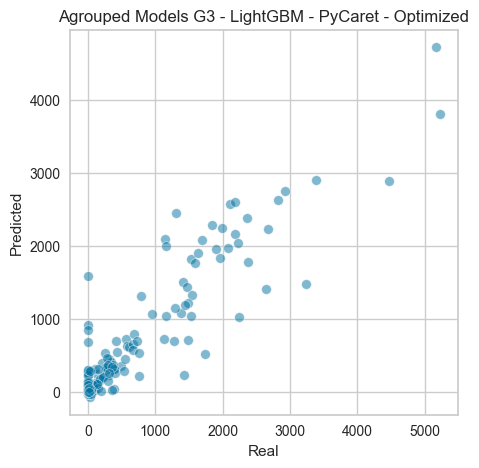

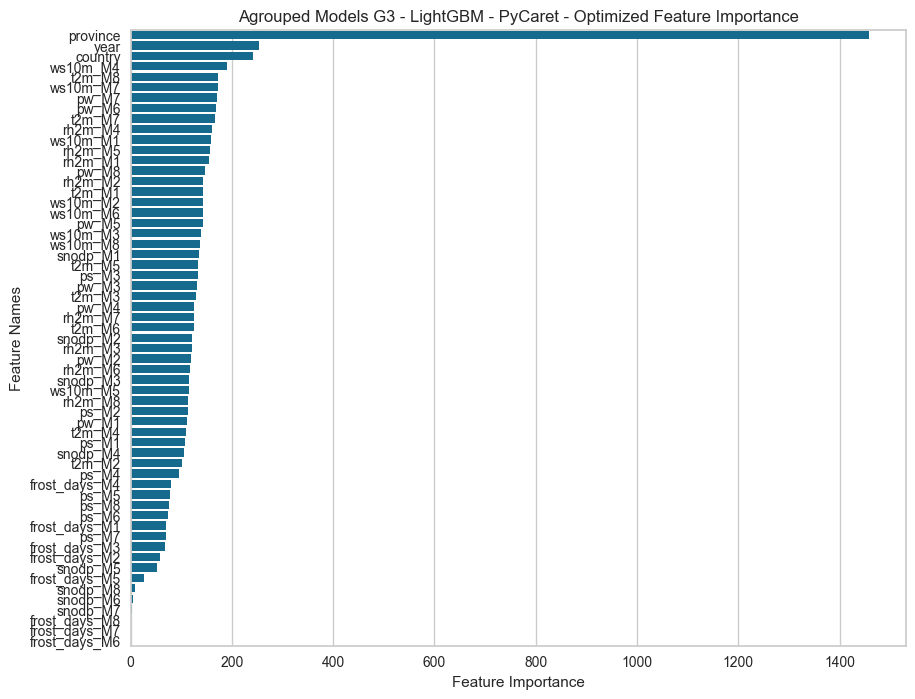

In [87]:
df3 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G3 - LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G3 - LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model_g3.feature_importances_, tuned_lgbm_model_g3.feature_names_in_, 'Agrouped Models G3 - LightGBM - PyCaret - Optimized')

### Model Registry

In [88]:
client = mlflow.tracking.MlflowClient()

In [89]:
experiments = (client.search_experiments())

In [90]:
experiment_g1 = list(filter(lambda k: k.name=='top_crop_group1', experiments))[0]
experiment_g2 = list(filter(lambda k: k.name=='top_crop_group2', experiments))[0]
experiment_g3 = list(filter(lambda k: k.name=='top_crop_group3', experiments))[0]

In [91]:
experiment_g1_id = experiment_g1.experiment_id
experiment_g2_id = experiment_g2.experiment_id
experiment_g3_id = experiment_g3.experiment_id

In [92]:
runs_g1 = mlflow.MlflowClient().search_runs(
    experiment_ids=experiment_g1_id,
    filter_string="",
    max_results=2,
    order_by=["metrics.MAE DESC"],
    run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY
)

runs_g2 = mlflow.MlflowClient().search_runs(
    experiment_ids=experiment_g2_id,
    filter_string="",
    max_results=2,
    order_by=["metrics.MAE DESC"],
    run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY
)

runs_g3 = mlflow.MlflowClient().search_runs(
    experiment_ids=experiment_g3_id,
    filter_string="",
    max_results=2,
    order_by=["metrics.MAE DESC"],
    run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY
)

In [94]:
run_g1 = runs_g1[0]
run_g2 = runs_g2[0]
run_g3 = runs_g3[0]

In [95]:
run_g1_id = run_g1.data.tags['Run ID']
run_g2_id = run_g2.data.tags['Run ID']
run_g3_id = run_g3.data.tags['Run ID']

In [96]:
mlflow.register_model(f'runs:/{run_g1_id}/model', 'top_crop_group1_model')
mlflow.register_model(f'runs:/{run_g2_id}/model', 'top_crop_group2_model')
mlflow.register_model(f'runs:/{run_g3_id}/model', 'top_crop_group3_model')

Successfully registered model 'top_crop_group1_model'.
2024/12/04 02:26:32 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation.                     Model name: top_crop_group1_model, version 1
Created version '1' of model 'top_crop_group1_model'.
Successfully registered model 'top_crop_group2_model'.
2024/12/04 02:26:33 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation.                     Model name: top_crop_group2_model, version 1
Created version '1' of model 'top_crop_group2_model'.
Successfully registered model 'top_crop_group3_model'.
2024/12/04 02:26:33 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation.                     Model name: top_crop_group3_model, version 1
Created version '1' of model 'top_crop_group3_model'.


<ModelVersion: creation_timestamp=1733297193493, current_stage='None', description='', last_updated_timestamp=1733297193493, name='top_crop_group3_model', run_id='d7a10c91751a4fda93642a91cc34730e', run_link='', source='s3://mlflow-forecast-yield-eu/6/d7a10c91751a4fda93642a91cc34730e/artifacts/model', status='READY', status_message='', tags={}, user_id='', version='1'>

In [97]:
client.transition_model_version_stage(
    name='top_crop_group1_model',
    version=1,
    stage="Production"
)

client.transition_model_version_stage(
    name='top_crop_group2_model',
    version=1,
    stage="Production"
)

client.transition_model_version_stage(
    name='top_crop_group3_model',
    version=1,
    stage="Production"
)

<ModelVersion: creation_timestamp=1733297193493, current_stage='Production', description='', last_updated_timestamp=1733297210674, name='top_crop_group3_model', run_id='d7a10c91751a4fda93642a91cc34730e', run_link='', source='s3://mlflow-forecast-yield-eu/6/d7a10c91751a4fda93642a91cc34730e/artifacts/model', status='READY', status_message='', tags={}, user_id='', version='1'>

### Saving Results from testing

In [100]:
logged_model_top_g1 = mlflow.pyfunc.load_model("models:/top_crop_group1_model/Production")
logged_model_top_g2 = mlflow.pyfunc.load_model("models:/top_crop_group2_model/Production")
logged_model_top_g3 = mlflow.pyfunc.load_model("models:/top_crop_group3_model/Production")

In [101]:
test_group1_prd = test_group1.copy()
test_group2_prd = test_group2.copy()
test_group3_prd = test_group3.copy()

In [102]:
test_group1_prd['prediction'] = logged_model_top_g1.predict(test_group1.drop(columns=['yield','country_code']))
test_group2_prd['prediction'] = logged_model_top_g2.predict(test_group2.drop(columns=['yield','country_code']))
test_group3_prd['prediction'] = logged_model_top_g3.predict(test_group3.drop(columns=['yield','country_code']))

MAE Test G1: 151.23693081649705


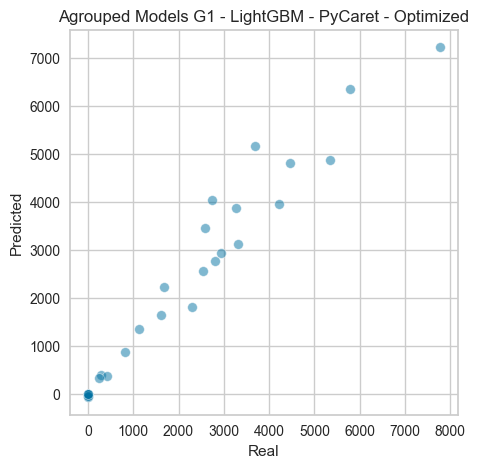

MAE Test G2: 346.10830075868824


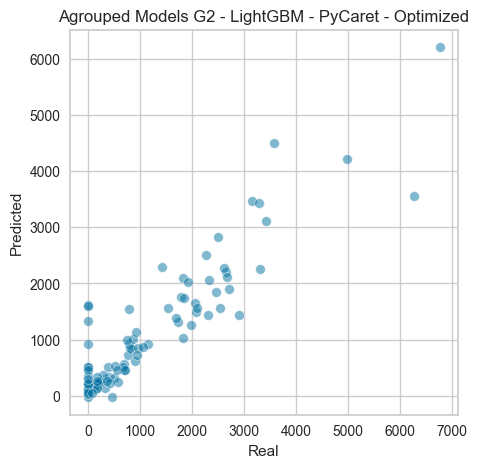

MAE Test G3: 165.88729792952591


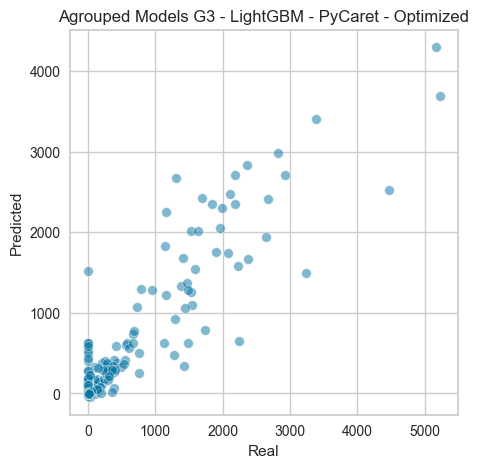

In [103]:
print('============================================================================================')
print('MAE Test G1:', mean_absolute_error(test_group1_prd['yield'], test_group1_prd['prediction']))
plot_predictions(test_group1_prd['yield'], test_group1_prd['prediction'], 
                 title='Agrouped Models G1 - LightGBM - PyCaret - Optimized')
print('============================================================================================')
print('MAE Test G2:', mean_absolute_error(test_group2_prd['yield'], test_group2_prd['prediction']))
plot_predictions(test_group2_prd['yield'], test_group2_prd['prediction'], 
                 title='Agrouped Models G2 - LightGBM - PyCaret - Optimized')
print('============================================================================================')
print('MAE Test G3:', mean_absolute_error(test_group3_prd['yield'], test_group3_prd['prediction']))
plot_predictions(test_group3_prd['yield'], test_group3_prd['prediction'], 
                 title='Agrouped Models G3 - LightGBM - PyCaret - Optimized')

In [104]:
top_crop_name

'cereals_for_the_production_of_grain_including_seed'

In [105]:
test_top_crops = pd.concat([test_group1_prd, test_group2_prd, test_group3_prd])
test_top_crops = test_top_crops.groupby(['country_code']).agg({'prediction':'sum'}).rename(columns={'prediction':'yield_forecast'}).reset_index()
test_top_crops.to_csv(f'../data/forecast/EU_2022_{top_crop_name}_forecast.csv', index=False)